# LangGraph Introduction (Gemini Edition)

This notebook teaches LangGraph concepts through progressively complex examples.
It has been adapted to use **Google Gemini** (via the `google-genai` SDK) instead
of OpenAI for every LLM call, and pulls its API keys/clients the same way your
RAG pipeline does.

## 📚 Table of Contents
1. **Single Node Graph** - Basic graph with one computation node (no LLM)
2. **Conditional Graph** - Routing between multiple paths based on conditions (no LLM)
3. **Agent Graph** - Gemini-powered LLM that can call tools (single-turn)
4. **ReAct Agent** - Multi-turn agent that loops between reasoning and tool use (Gemini)

## 🔑 Key Concepts
- **State**: Shared memory that flows through the graph
- **Nodes**: Computations (LLM calls, tool execution, custom functions)
- **Edges**: Control flow between nodes (fixed or conditional)
- **Tools**: Python functions the LLM can call
- **ToolNode**: Built-in node that executes tools
- **ReAct Pattern**: Reasoning → Acting → Observing → Reasoning...

> ⚠️ **Note on outputs**: This notebook was regenerated in a sandboxed
> environment with no route to `generativelanguage.googleapis.com` and without
> your local `utils/utils.py`, so the cells below have **not** been executed
> here — outputs are empty. Run it locally with your `.env` populated
> (`GOOGLE_API_KEY`, `GROQ_API_KEY`) and `utils/utils.py` on your `PYTHONPATH`.

---

### Import Dependencies & Configure Clients

In [3]:
! uv pip install langgraph langchain

Using Python 3.12.3 environment at: /home/rayudu/otherwork_assignment_all_jobs/Todo/ai_multi_agent_shopping_assistant/.venv
Resolved 36 packages in 75ms                                         
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)-------------------     0 B/133.70 KiB          
⠙ Preparing packages... (0/1)------------------- 16.00 KiB/133.70 KiB        
⠙ Preparing packages... (0/1)------------------- 32.00 KiB/133.70 KiB        
⠙ Preparing packages... (0/1)------------------- 48.00 KiB/133.70 KiB        
⠙ Preparing packages... (0/1)---------------- 64.00 KiB/133.70 KiB        
⠙ Preparing packages... (0/1)0m------------- 80.00 KiB/133.70 KiB        
⠙ Preparing packages... (0/1)---------- 96.00 KiB/133.70 KiB        
⠙ Preparing packages... (0/1)---------- 112.00 KiB/133.70 KiB       
⠙ Preparing packages... (0/1)---------- 128.00 KiB/133.70 KiB       
⠙ Preparing packages... (0/1)---------- 133.70 KiB/133.70

In [5]:
! uv pip install --upgrade langchain-core langchain langgraph

Using Python 3.12.3 environment at: /home/rayudu/otherwork_assignment_all_jobs/Todo/ai_multi_agent_shopping_assistant/.venv
Resolved 36 packages in 107ms                                        
⠙ Preparing packages... (0/5)                                                   
⠙ Preparing packages... (0/5)-------------------     0 B/122.86 KiB          
⠙ Preparing packages... (0/5)------------------- 14.79 KiB/122.86 KiB        
⠙ Preparing packages... (0/5)------------------- 30.79 KiB/122.86 KiB        
⠙ Preparing packages... (0/5)------------------- 46.79 KiB/122.86 KiB        
⠙ Preparing packages... (0/5)--------------- 62.79 KiB/122.86 KiB        
⠙ Preparing packages... (0/5)----------- 78.79 KiB/122.86 KiB        
⠙ Preparing packages... (0/5)----------- 78.79 KiB/122.86 KiB        
anyio                ------------------------------ 78.79 KiB/122.86 KiB
⠙ Preparing packages... (0/5)-------------------     0 B/241.67 KiB          
anyio                ---------------------------

In [ ]:
import os
import json
import random

from dotenv import load_dotenv

# --- Gemini (google-genai) instead of OpenAI ---
from google import genai
from google.genai import types

# --- LangSmith, kept for pulling eval datasets etc. ---
from langsmith import Client

from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_core.messages import AIMessage, ToolMessage
from langchain_core.messages import convert_to_openai_messages, convert_to_messages

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List
from IPython.display import Image, display
from operator import add

from utils.utils import get_tool_descriptions, format_ai_message

# ---------------------------------------------------------------------------
# Environment / API clients
# ---------------------------------------------------------------------------
load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
if not GOOGLE_API_KEY:
    raise ValueError("GOOGLE_API_KEY not found in .env file!")

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY not found in .env file!")

# Native google-genai client -> used for the RAG pipeline itself
# (embeddings + answer generation), and reused here for every agent node.
gemini_client = genai.Client(api_key=GOOGLE_API_KEY)

# LangSmith client -> used to pull the evaluation dataset
ls_client = Client()

# Model used throughout this notebook for structured-output agent calls.
# Swap for "gemini-2.0-flash-lite" / "gemini-1.5-pro" etc. as needed.
GEMINI_MODEL = "gemini-2.0-flash"

print("Gemini client ready. Using model:", GEMINI_MODEL)

ImportError: cannot import name '_extract_reasoning_from_additional_kwargs' from 'langchain_core.messages.base' (/home/rayudu/otherwork_assignment_all_jobs/Todo/ai_multi_agent_shopping_assistant/.venv/lib/python3.12/site-packages/langchain_core/messages/base.py)

In [2]:
import os
import json
import random

from dotenv import load_dotenv

# --- Gemini (google-genai) instead of OpenAI ---
from google import genai
from google.genai import types

# --- LangSmith, kept for pulling eval datasets etc. ---
from langsmith import Client

from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_core.messages import AIMessage, ToolMessage
from langchain_core.messages import convert_to_openai_messages, convert_to_messages

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List
from IPython.display import Image, display
from operator import add

from utils.utils import get_tool_descriptions, format_ai_message

# ---------------------------------------------------------------------------
# Environment / API clients
# ---------------------------------------------------------------------------
load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
if not GOOGLE_API_KEY:
    raise ValueError("GOOGLE_API_KEY not found in .env file!")

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY not found in .env file!")

# Native google-genai client -> used for the RAG pipeline itself
# (embeddings + answer generation), and reused here for every agent node.
gemini_client = genai.Client(api_key=GOOGLE_API_KEY)

# LangSmith client -> used to pull the evaluation dataset
ls_client = Client()

# Model used throughout this notebook for structured-output agent calls.
# Swap for "gemini-2.0-flash-lite" / "gemini-1.5-pro" etc. as needed.
GEMINI_MODEL = "gemini-2.0-flash"

print("Gemini client ready. Using model:", GEMINI_MODEL)

Gemini client ready. Using model: gemini-2.0-flash


In [7]:
!uv pip uninstall langchain-core langchain langgraph -y
!uv pip install --upgrade "langchain-core>=1.1" langchain langgraph

error: unexpected argument '-y' found

  tip: to pass '-y' as a value, use '-- -y'

Usage: uv pip uninstall [OPTIONS] <PACKAGE|--requirements <REQUIREMENTS>>

For more information, try '--help'.
Using Python 3.12.3 environment at: /home/rayudu/otherwork_assignment_all_jobs/Todo/ai_multi_agent_shopping_assistant/.venv
Resolved 36 packages in 129ms                                        
Checked 36 packages in 0.36ms


### Single Node Graph

**What is LangGraph?**
- LangGraph is a framework for building agent workflows as computational graphs
- Graphs have **nodes** (computations like LLM calls, tool calls, or regular code) and **edges** (define control flow)
- It's a **state machine**: each computation mutates the graph's state as it flows through
- You define a state schema, then nodes modify that state as the graph executes

**This example**: A simple graph with just one node that concatenates two strings from the state. No LLM calls yet, so nothing here needed to change for the Gemini migration.

In [3]:
# Define the State schema using Pydantic
# The state is like a shared memory that flows through the graph
# Each node can read from and write to this state
class State(BaseModel):
    message: str      # Input message
    answer: str = ""  # Result (starts as empty string)
    vibe: str         # Additional vibe to append

In [4]:
# Node functions define the computation that happens at each graph node
# They receive the current state and return a dict with updates
# The returned dict OVERWRITES matching keys in the state
def append_vibes_to_query(state: State) -> dict:
    # This node concatenates message and vibe, stores result in "answer"
    return {
        "answer": f"{state.message} {state.vibe}"
    }
    # Whatever keys you return here will UPDATE the state
    # Keys not returned remain unchanged

In [5]:
# Step 1: Initialize the graph with the State schema
workflow = StateGraph(State)

# Step 2: Add nodes (computations)
# add_node(name, function) - name is a string identifier, function is the computation
workflow.add_node("append_vibes_to_query", append_vibes_to_query)

# Step 3: Add edges (control flow)
# START and END are special nodes imported from langgraph
# START -> append_vibes_to_query: Graph enters here
workflow.add_edge(START, "append_vibes_to_query")
# append_vibes_to_query -> END: Graph exits here
workflow.add_edge("append_vibes_to_query", END)

# Step 4: Compile the graph to make it executable
graph = workflow.compile()

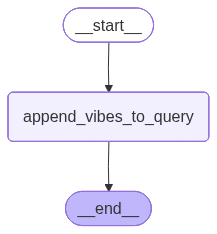

In [6]:
# Visualize the graph structure
# This shows: START -> append_vibes_to_query -> END
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
# Define the initial state as a dictionary
# This sets the starting values before the graph runs
initial_state = {
    "message": "Give me some vibes!",
    "vibe": "I'm feeling like a badass today!"
}
# Note: "answer" is not provided here, so it defaults to ""

In [8]:
# Execute the graph with the initial state
# Flow: initial_state -> START -> append_vibes_to_query -> END -> result
result = graph.invoke(initial_state)

In [9]:
print(result)
result

{'message': 'Give me some vibes!', 'answer': "Give me some vibes! I'm feeling like a badass today!", 'vibe': "I'm feeling like a badass today!"}


{'message': 'Give me some vibes!',
 'answer': "Give me some vibes! I'm feeling like a badass today!",
 'vibe': "I'm feeling like a badass today!"}

In [10]:
# Demonstration: Even if we provide "answer" in initial state,
# it will be OVERWRITTEN by the node function
initial_state = {
    "message": "Give me some vibes!",
    "answer": "abc",  # This will be overwritten!
    "vibe": "I'm feeling like a badass today!"
}

In [11]:
result = graph.invoke(initial_state)

In [12]:
print(result)
result

{'message': 'Give me some vibes!', 'answer': "Give me some vibes! I'm feeling like a badass today!", 'vibe': "I'm feeling like a badass today!"}


{'message': 'Give me some vibes!',
 'answer': "Give me some vibes! I'm feeling like a badass today!",
 'vibe': "I'm feeling like a badass today!"}

### Conditional Graph

**What's new here?**
- Instead of a fixed path, the graph can take different routes based on a condition
- We use `add_conditional_edges()` to define routing logic
- A **router function** decides which path to take
- Visualized as dotted arrows (showing multiple possible paths)

This section is also LLM-free (the router uses `random.choice`), so it's identical to the original notebook.

In [13]:
class State(BaseModel):
    message: str
    answer: str = ""

In [14]:
def append_vibes_to_query(state: State) -> dict:

    return {
        "answer": state.message
    }

In [15]:
# Router function: decides which node to route to next
# The return type hint (Literal) shows the possible paths
# This function is called AFTER append_vibes_to_query executes
def router(state: State) -> Literal["append_vibe_1", "append_vibe_2", "append_vibe_3"]:
    # List of possible next nodes
    vibes = ["append_vibe_1", "append_vibe_2", "append_vibe_3"]

    # Randomly select one (in real apps, this would be based on logic/classification)
    vibe_path = random.choice(vibes)

    # The returned string MUST match a node name for routing to work
    return vibe_path

In [16]:
def append_vibe_1(state: State) -> dict:

    vibe = "I'm feeling like a badass today!"

    return {
        "answer": f"{state.answer} {vibe}"
    }

def append_vibe_2(state: State) -> dict:

    vibe = "I'm feeling like a boss today!"

    return {
        "answer": f"{state.answer} {vibe}"
    }

def append_vibe_3(state: State) -> dict:

    vibe = "I'm feeling like a legend today!"

    return {
        "answer": f"{state.answer} {vibe}"
    }

In [17]:
workflow = StateGraph(State)

# Add all the nodes
workflow.add_node("append_vibes_to_query", append_vibes_to_query)
workflow.add_node("append_vibe_1", append_vibe_1)
workflow.add_node("append_vibe_2", append_vibe_2)
workflow.add_node("append_vibe_3", append_vibe_3)

# Add CONDITIONAL edges - the key difference!
# Syntax: add_conditional_edges(source_node, router_function, path_map)
workflow.add_conditional_edges(
    "append_vibes_to_query",  # From this node
    router,                    # Use this function to decide the route
    {
        # Map router return values to node names
        # If router returns "append_vibe_1", go to "append_vibe_1" node
        "append_vibe_1": "append_vibe_1",
        "append_vibe_2": "append_vibe_2",
        "append_vibe_3": "append_vibe_3"
    }
    # Note: This dict is optional if return values exactly match node names
)

# Fixed edges (always execute)
workflow.add_edge(START, "append_vibes_to_query")  # Always start here

# All vibe nodes lead to END
workflow.add_edge("append_vibe_1", END)
workflow.add_edge("append_vibe_2", END)
workflow.add_edge("append_vibe_3", END)

graph = workflow.compile()

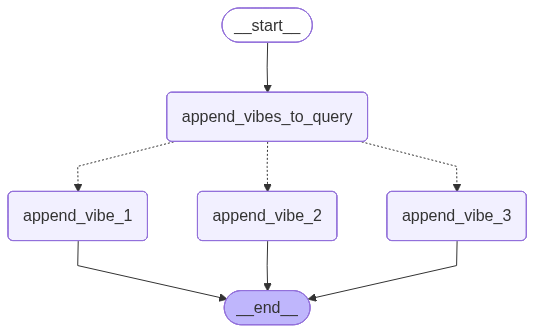

In [18]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
initial_state = {
    "message": "I am here to add some vibes:",
}

In [20]:
result = graph.invoke(initial_state)

In [21]:
print(result)
result

{'message': 'I am here to add some vibes:', 'answer': "I am here to add some vibes: I'm feeling like a legend today!"}


{'message': 'I am here to add some vibes:',
 'answer': "I am here to add some vibes: I'm feeling like a legend today!"}

In [22]:
result = graph.invoke(initial_state)

In [23]:
print(result)
result

{'message': 'I am here to add some vibes:', 'answer': "I am here to add some vibes: I'm feeling like a legend today!"}


{'message': 'I am here to add some vibes:',
 'answer': "I am here to add some vibes: I'm feeling like a legend today!"}

### Agent Graph

**What's new here? TOOL CALLING!**
- An **agent** can decide to use tools (functions) to accomplish tasks
- The LLM is given tool descriptions and decides which tools to call
- The graph routes between: Agent → Tools → End
- This is a **single-turn** agent (calls tools once, then ends)

**Key Components:**
1. **Tool function**: Regular Python function with docstring (describes what it does)
2. **Tool descriptions**: Convert function to JSON schema for LLM
3. **Agent node**: Gemini call that decides whether/which tools to call
4. **ToolNode**: Executes the tools
5. **Router**: Decides if we need tools or are done

**Gemini vs OpenAI/instructor difference**: instead of wrapping `OpenAI()` with
`instructor.from_openai(...)`, we call `gemini_client.models.generate_content(...)`
directly and pass our Pydantic `AgentResponse` model as `response_schema` with
`response_mime_type="application/json"`. Gemini returns the parsed object on
`response.parsed` — no extra library needed.

> ⚠️ **Important companion fix required outside this notebook**
> 
> The public Gemini API rejects any Pydantic field that produces an open-ended
> JSON Schema `object` (i.e. a raw `dict` field) inside `response_schema`, with:
> `ValueError: additionalProperties is not supported in the Gemini API.`
>
> To fix this, `ToolCall.arguments` below has been changed from `dict` to `str`
> (a JSON-encoded string), and the agent prompts now instruct Gemini to encode
> arguments that way. That means **`utils/utils.py`'s `format_ai_message()`
> function must also be updated** to parse that string back into a dict before
> handing it to LangChain's `AIMessage`/`ToolNode` (which still expect a real
> `dict` for `tool_calls[i]["args"]`). Concretely, add `import json` at the top
> of that file and wrap the argument value like so:
>
> ```python
> # utils/utils.py
> import json
>
> def format_ai_message(agent_response):
>     tool_calls = [
>         {
>             "name": tc.name,
>             "args": json.loads(tc.arguments),  # was: tc.arguments
>             "id": f"call_{i}",
>         }
>         for i, tc in enumerate(agent_response.tool_calls)
>     ]
>     return AIMessage(content=agent_response.answer, tool_calls=tool_calls)
> ```
>
> After editing `utils/utils.py`, **restart the kernel** (Python caches
> imported modules, so re-running cells alone won't pick up the change).


In [31]:
# TOOL DEFINITION
# A tool is just a Python function with a good docstring
# The docstring is crucial - it tells the LLM what the tool does!
def append_vibes(query: str, vibe: str) -> str:
    """Takes in a query and a vibe and returns a string with the query and vibe appended.

    Args:
        query: The query to append the vibe to.
        vibe: The vibe to append to the query.

    Returns:
        A string with the query and vibe appended.
    """
    # The actual implementation is simple
    return f"{query} {vibe}"

# The LLM will read this docstring to understand:
# - What the tool does
# - What parameters it needs
# - What it returns

In [25]:
# TOOL DESCRIPTIONS
# Convert Python functions into JSON schema that LLMs can understand
# This parses the docstring and type hints to create structured descriptions
tool_descriptions_preview = get_tool_descriptions([append_vibes])
print(json.dumps(tool_descriptions_preview, indent=2))
tool_descriptions_preview

# Output shows:
# - name: Function name
# - description: From docstring
# - parameters: From function signature + docstring
# - required: Which params are mandatory
# - returns: What the function returns

[
  {
    "name": "append_vibes",
    "description": "Takes in a query and a vibe and returns a string with the query and vibe appended.",
    "parameters": {
      "type": "object",
      "properties": {
        "query": {
          "type": "string",
          "description": "The query to append the vibe to."
        },
        "vibe": {
          "type": "string",
          "description": "The vibe to append to the query."
        }
      }
    },
    "required": [
      "query",
      "vibe"
    ],
    "returns": {
      "type": "string",
      "description": "A string with the query and vibe appended."
    }
  }
]


[{'name': 'append_vibes',
  'description': 'Takes in a query and a vibe and returns a string with the query and vibe appended.',
  'parameters': {'type': 'object',
   'properties': {'query': {'type': 'string',
     'description': 'The query to append the vibe to.'},
    'vibe': {'type': 'string',
     'description': 'The vibe to append to the query.'}}},
  'required': ['query', 'vibe'],
  'returns': {'type': 'string',
   'description': 'A string with the query and vibe appended.'}}]

In [32]:
# Data structures for tool calling

# Represents a single tool call (what tool + what arguments)
class ToolCall(BaseModel):
    name: str           # Tool function name
    arguments: str      # JSON-encoded string of arguments (Gemini's API rejects
                        # open-ended `dict` fields in response_schema with:
                        # "ValueError: additionalProperties is not supported
                        # in the Gemini API." -- so we ask for a JSON string
                        # instead and json.loads() it back out downstream).

# The LLM's response can contain text AND tool calls
class AgentResponse(BaseModel):
    answer: str                                    # Text response from LLM
    tool_calls: List[ToolCall] = Field(default_factory=list)  # Tools it wants to call

# State for the agent graph
class State(BaseModel):
    # Annotated[List[Any], add] means: APPEND to list instead of overwriting
    messages: Annotated[List[Any], add] = []       # Conversation history
    message: str = ""                               # Current user message
    iteration: int = 0                              # Track how many times agent ran
    answer: str = ""                                # Final answer
    available_tools: List[Dict[str, Any]] = []      # Tool descriptions for LLM
    tool_calls: List[ToolCall] = []                 # Tools the LLM decided to call

In [33]:
# AGENT NODE - The brain of the operation! (Gemini-powered)
# This is where Gemini decides whether to call tools
def agent_node(state: State) -> dict:

    # System prompt that instructs the LLM on how to use tools.
    # We keep the same Jinja2 templating approach as before.
    prompt_template = """You are an assistant that is generating vibes for a user.

You will be given a selection of tools you can use to add vibes to a user's query.

<Available tools>
{{ available_tools | tojson }}
</Available tools>

Instructions:
- You need to use the tools to add vibes to the user's query.
- Add a random vibe to the user's query.
- `arguments` in each tool_call must be a single JSON-encoded STRING of the
  tool's parameters, e.g. "{\"query\": \"...\", \"vibe\": \"...\"}" -- not a
  nested JSON object.
- Respond ONLY with a JSON object matching the required schema (do not add any
  extra commentary, markdown fences, or preamble).
"""

    # Render the prompt with available tool descriptions
    template = Template(prompt_template)
    system_prompt = template.render(
        available_tools=state.available_tools  # Inject tool descriptions
    )

    # Call Gemini with structured output:
    # - system_instruction carries the "system prompt"
    # - contents carries the actual user turn
    # - response_schema=AgentResponse makes Gemini return JSON matching our
    #   Pydantic model, and response.parsed gives us the model instance directly
    response = gemini_client.models.generate_content(
        model=GEMINI_MODEL,
        contents=[
            {"role": "user", "parts": [{"text": state.message}]}
        ],
        config=types.GenerateContentConfig(
            system_instruction=system_prompt,
            temperature=0.5,
            response_mime_type="application/json",
            response_schema=AgentResponse,
        ),
    )

    # response.parsed is already an AgentResponse instance (Gemini SDK parses
    # the JSON against the Pydantic schema for us)
    agent_response: AgentResponse = response.parsed

    # Convert the structured response to LangChain's AIMessage format
    # This format is compatible with LangGraph's ToolNode
    ai_message = format_ai_message(agent_response)

    # Return updates to state:
    # - messages: Add the AI's response to conversation history
    # - tool_calls: Store which tools the LLM wants to call
    return {
        "messages": [ai_message],       # APPEND to messages list (because of Annotated[List, add])
        "tool_calls": agent_response.tool_calls  # OVERWRITE tool_calls list
    }

#### Short explainer on message types and formatting

**Why do we need different message formats?**
- LLMs use standard message formats: `[{"role": "user", "content": "..."}, {"role": "assistant", "content": "..."}]`
- LangChain uses typed message objects: `HumanMessage`, `AIMessage`, `ToolMessage`
- LangGraph's `ToolNode` expects LangChain format (AIMessage with tool_calls)
- Gemini's own `contents` format uses `{"role": "user"/"model", "parts": [{"text": ...}]}` — we convert to/from that at the edges, but internally the graph still speaks LangChain messages

**Key functions:**
- `convert_to_messages()`: Dict → LangChain messages
- `convert_to_openai_messages()`: LangChain messages → OpenAI-style dict format (still useful as a neutral intermediate representation, independent of which model API you call)
- `format_ai_message()`: Structured response → AIMessage with tool_calls

In [34]:
conversation  = [
    {'role': 'user', 'content': 'Give me some vibes!'},
    {'role': 'assistant', 'content': 'I am here to add some vibes:'},
    {'role': 'user', 'content': 'I am feeling like a badass today!'}
]

In [29]:
print(convert_to_messages(conversation))
convert_to_messages(conversation)

[HumanMessage(content='Give me some vibes!', additional_kwargs={}, response_metadata={}), AIMessage(content='I am here to add some vibes:', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='I am feeling like a badass today!', additional_kwargs={}, response_metadata={})]


[HumanMessage(content='Give me some vibes!', additional_kwargs={}, response_metadata={}),
 AIMessage(content='I am here to add some vibes:', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I am feeling like a badass today!', additional_kwargs={}, response_metadata={})]

In [30]:
print(convert_to_openai_messages(convert_to_messages(conversation)))
convert_to_openai_messages(convert_to_messages(conversation))

[{'role': 'user', 'content': 'Give me some vibes!'}, {'role': 'assistant', 'content': 'I am here to add some vibes:'}, {'role': 'user', 'content': 'I am feeling like a badass today!'}]


[{'role': 'user', 'content': 'Give me some vibes!'},
 {'role': 'assistant', 'content': 'I am here to add some vibes:'},
 {'role': 'user', 'content': 'I am feeling like a badass today!'}]

In [35]:
# Create a dummy AgentResponse to show how format_ai_message works
# This simulates what Gemini would return (already parsed into our Pydantic model)
dummy_response = AgentResponse(
    answer="I am here to add some vibes:",  # Text response
    tool_calls=[ToolCall(  # Tool the LLM wants to call
        name="append_vibes",
        arguments=json.dumps({"query": "Give me some vibes!", "vibe": "I am feeling like a badass today!"})
    )]
)

In [36]:
print(dummy_response)
dummy_response

answer='I am here to add some vibes:' tool_calls=[ToolCall(name='append_vibes', arguments={'query': 'Give me some vibes!', 'vibe': 'I am feeling like a badass today!'})]


AgentResponse(answer='I am here to add some vibes:', tool_calls=[ToolCall(name='append_vibes', arguments={'query': 'Give me some vibes!', 'vibe': 'I am feeling like a badass today!'})])

In [37]:
# Convert to AIMessage format that LangGraph's ToolNode can understand
# Notice:
# - content: The text from answer
# - tool_calls: List of tools with auto-generated IDs
# - This format is what ToolNode expects!
print(format_ai_message(dummy_response))
format_ai_message(dummy_response)

content='I am here to add some vibes:' additional_kwargs={} response_metadata={} tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes!', 'vibe': 'I am feeling like a badass today!'}, 'id': 'call_0', 'type': 'tool_call'}] invalid_tool_calls=[]


AIMessage(content='I am here to add some vibes:', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes!', 'vibe': 'I am feeling like a badass today!'}, 'id': 'call_0', 'type': 'tool_call'}], invalid_tool_calls=[])

#### End of Short explainer on message types and formatting

In [38]:
# TOOL ROUTER - Decides the next step after agent runs
def tool_router(state: State) -> str:
    """Decide whether to continue or end"""

    # Check if the LLM wants to call any tools
    if len(state.tool_calls) > 0:
        return "tools"  # Route to tool_node to execute the tools
    else:
        return "end"    # No tools needed, we're done!

In [39]:
workflow = StateGraph(State)

# Setup tools
tools = [append_vibes]  # List of actual Python functions
tool_node = ToolNode(tools)  # LangGraph's built-in node for executing tools
                             # It reads AIMessage.tool_calls and executes them!
tool_descriptions = get_tool_descriptions(tools)  # JSON descriptions for the LLM

# Add nodes
workflow.add_node("agent_node", agent_node)  # Gemini decides what to do
workflow.add_node("tool_node", tool_node)    # Executes the tools

# Entry point
workflow.add_edge(START, "agent_node")  # Always start with the agent

# Conditional routing from agent
workflow.add_conditional_edges(
    "agent_node",   # After agent runs
    tool_router,    # Use this function to decide next step
    {
        "tools": "tool_node",  # If tools needed → execute tools
        "end": END              # If no tools needed → end
    }
)

# After tools execute, end the graph (single-turn agent)
workflow.add_edge("tool_node", END)

graph = workflow.compile()

# FLOW:
# START → agent_node → [tool_router decides]
#                    ↓
#         if tools: tool_node → END
#         if no tools: END

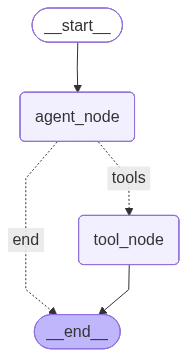

In [40]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [41]:
# Run the agent graph
initial_state = {
    "message": "Give me some vibes!",
    "available_tools": tool_descriptions  # Give Gemini info about available tools
}
result = graph.invoke(initial_state)

# What happens:
# 1. agent_node: Gemini sees the message and tool descriptions, decides to call append_vibes
# 2. tool_router: Sees tool_calls is not empty, routes to "tools"
# 3. tool_node: Executes append_vibes with the arguments from tool_calls
# 4. Graph ends, returns final state

ValueError: additionalProperties is not supported in the Gemini API.

In [42]:
# NOTE: This cell used to be a leftover, misplaced attempt at a fix
# (adding model_config={"extra": "ignore"} and redefining ToolCall/AgentResponse
# with arguments: dict). That did NOT fix the Gemini error, for two reasons:
#   1. `extra="ignore"` controls how *incoming* extra fields are handled --
#      it has no effect on the JSON Schema Pydantic generates for `arguments`.
#   2. It ran AFTER the graph above was already compiled/invoked with the
#      original ToolCall class, so it wouldn't even apply at runtime.
# The real fix (arguments: dict -> arguments: str) is now applied directly
# in the ToolCall class definition above (Cell defining ToolCall/AgentResponse/State),
# so this cell is no longer needed and is left empty intentionally.


In [ ]:
# Look at the result!
# messages contains:
# 1. AIMessage: What the agent decided (including tool_calls)
# 2. ToolMessage: The result of executing append_vibes
print(result)
result

### Agent Graph with Loopback from Tools (ReAct Agent)

**What's new here? MULTI-TURN AGENT!**
- Previous example: Agent → Tools → End (single turn)
- This example: Agent → Tools → Agent → ... (can loop!)
- This is the **ReAct pattern** (Reasoning + Acting)
- The agent can:
  1. Call a tool
  2. See the tool result
  3. Reason about it
  4. Decide to call another tool OR give final answer

**Key Difference:**
- `workflow.add_edge("tool_node", "agent_node")` - Tools loop back to agent!
- Router now checks iteration count to prevent infinite loops
- For Gemini, we now need to translate the *whole* running message history
  (including prior tool results) into Gemini's `contents` format on every turn,
  since Gemini is stateless between `generate_content` calls just like the
  OpenAI API was.

In [ ]:
def append_vibes(query: str, vibe: str) -> str:
    """Takes in a query and a vibe and returns a string with the query and vibe appended.

    Args:
        query: The query to append the vibe to.
        vibe: The vibe to append to the query.

    Returns:
        A string with the query and vibe appended.
    """

    return f"{query} {vibe}"

In [ ]:
class ToolCall(BaseModel):
    name: str
    arguments: str   # JSON-encoded string -- see note in the single-turn
                     # ToolCall definition above for why this isn't `dict`.

class AgentResponse(BaseModel):
    answer: str
    tool_calls: List[ToolCall] = Field(default_factory=list)

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    message: str = ""
    iteration: int = 0
    answer: str = ""
    available_tools: List[Dict[str, Any]] = []
    tool_calls: List[ToolCall] = []

In [ ]:
def _messages_to_gemini_contents(messages: List[Any]) -> List[Dict[str, Any]]:
    """Convert LangChain-style messages (Human/AI/Tool) into Gemini's
    `contents` format: a list of {"role": "user"/"model", "parts": [...]}.

    Gemini only knows "user" and "model" roles, so both HumanMessages and
    ToolMessages are folded into "user" turns (tool results are just more
    information for the model to react to).
    """
    openai_style = convert_to_openai_messages(messages)
    contents = []
    for m in openai_style:
        role = m.get("role")
        text = m.get("content") or ""

        if role == "assistant":
            gemini_role = "model"
        else:
            gemini_role = "user"

        if not text and role == "tool":
            # Fall back to dumping the whole message if content is empty
            text = json.dumps(m)

        contents.append({"role": gemini_role, "parts": [{"text": text}]})
    return contents

In [ ]:
# REACT AGENT NODE - Can reason about tool results! (Gemini-powered)
def agent_node(state: State) -> dict:

    prompt_template = """You are a assistant that is generating vibes for a user.

You will be given a selection of tools you can use to add vibes to a user's query.

<Available tools>
{{ available_tools | tojson }}
</Available tools>

Instructions:
- You need to use the tools to add vibes to the user's query.
- Add a random vibe to the user's query.
- You must return a tool call in the first interaction.
- `arguments` in each tool_call must be a single JSON-encoded STRING of the
  tool's parameters, e.g. "{\"query\": \"...\", \"vibe\": \"...\"}" -- not a
  nested JSON object.
- Respond ONLY with a JSON object matching the required schema (no markdown
  fences, no extra commentary).
"""

    template = Template(prompt_template)
    system_prompt = template.render(
        available_tools=state.available_tools
    )

    # KEY DIFFERENCE: Include message history!
    # Convert the full running conversation (including previous tool results)
    # into Gemini's contents format.
    if state.messages:
        contents = _messages_to_gemini_contents(state.messages)
    else:
        contents = [{"role": "user", "parts": [{"text": state.message}]}]

    # Now Gemini can see:
    # 1. The original user message
    # 2. Its previous tool calls
    # 3. The tool results
    # And decide what to do next!
    response = gemini_client.models.generate_content(
        model=GEMINI_MODEL,
        contents=contents,
        config=types.GenerateContentConfig(
            system_instruction=system_prompt,
            temperature=0.5,
            response_mime_type="application/json",
            response_schema=AgentResponse,
        ),
    )

    agent_response: AgentResponse = response.parsed

    ai_message = format_ai_message(agent_response)

    return {
        "messages": [ai_message],
        "tool_calls": agent_response.tool_calls,
        "iteration": state.iteration + 1,  # Track iterations
        "answer": agent_response.answer
    }

In [ ]:
# REACT ROUTER - Prevents infinite loops!
def tool_router(state: State) -> str:
    """Decide whether to continue or end"""

    # Safety check: Don't loop forever
    if state.iteration > 1:
        return "end"  # After 2 iterations, stop
    # Check if agent wants to call tools
    elif len(state.tool_calls) > 0:
        return "tools"  # Call the tools
    else:
        return "end"  # Agent gave final answer, we're done

    # This allows: Agent (iter 1) → Tools → Agent (iter 2) → End

In [ ]:
workflow = StateGraph(State)

tools = [append_vibes]
tool_node = ToolNode(tools)
tool_descriptions = get_tool_descriptions(tools)

workflow.add_node("agent_node", agent_node)
workflow.add_node("tool_node", tool_node)

workflow.add_edge(START, "agent_node")

# Same conditional edge from agent
workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)

# THE KEY DIFFERENCE: Tools loop back to agent!
# This creates: Agent → Tools → Agent → Tools → ... (until router says "end")
workflow.add_edge("tool_node", "agent_node")  # LOOPBACK!

graph = workflow.compile()

# FLOW (ReAct Pattern):
# START → agent_node (iter=1) → [decides to use tool]
#           ↓
#         tool_node (executes tool)
#           ↓
#         agent_node (iter=2) → [sees tool result, gives final answer]
#           ↓
#         END

In [ ]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# Run the ReAct agent
initial_state = {
    "message": "Give me some vibes!",
    "available_tools": tool_descriptions
}
result = graph.invoke(initial_state)

# What happens (multi-turn):
# Iteration 1: Agent calls append_vibes tool
# Tool executes: Returns "Give me some vibes! <some vibe>"
# Iteration 2: Agent sees tool result, provides final answer
# Router: iteration > 1, so END

In [ ]:
# Look at the messages - you can see the full conversation!
# 1. AIMessage (iter 1): Agent decides to call append_vibes
# 2. ToolMessage: Tool result
# 3. AIMessage (iter 2): Agent's final answer after seeing tool result
#
# This is the ReAct pattern in action: Reason → Act → Observe → Reason → Answer
print(result)
result